In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Total messages processed: 1860
Total messages dropped: 0
      index  Sending_Timestamp  Receiving_Timestamp  latency  grupo  \
0         0      1779796312311        1779796312344       33     10   
1         1      1779796312811        1779796312844       33     10   
2         2      1779796313312        1779796313344       32     10   
3         3      1779796313814        1779796313845       31     10   
4         4      1779796314314        1779796314345       31     10   
...     ...                ...                  ...      ...    ...   
1855   1855      1779797393281        1779797393330       49   1000   
1856   1856      1779797393781        1779797393830       49   1000   
1857   1857      1779797394281        1779797394331       50   1000   
1858   1858      1779797394781        1779797394842       61   1000   
1859   1859      1779797395301        1779797395345       44   1000   

      arrived_timestamp  leaving_timestamp  latency_s_s  
0      7250865323746414   725086

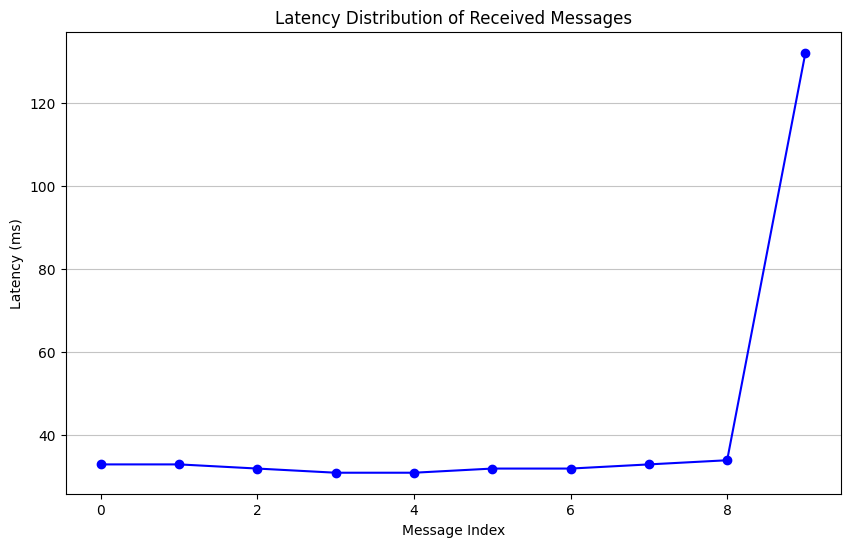

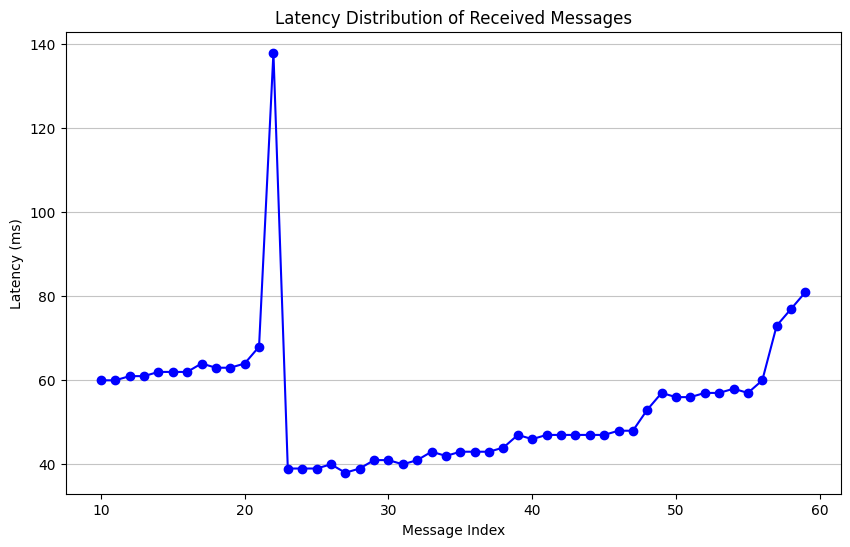

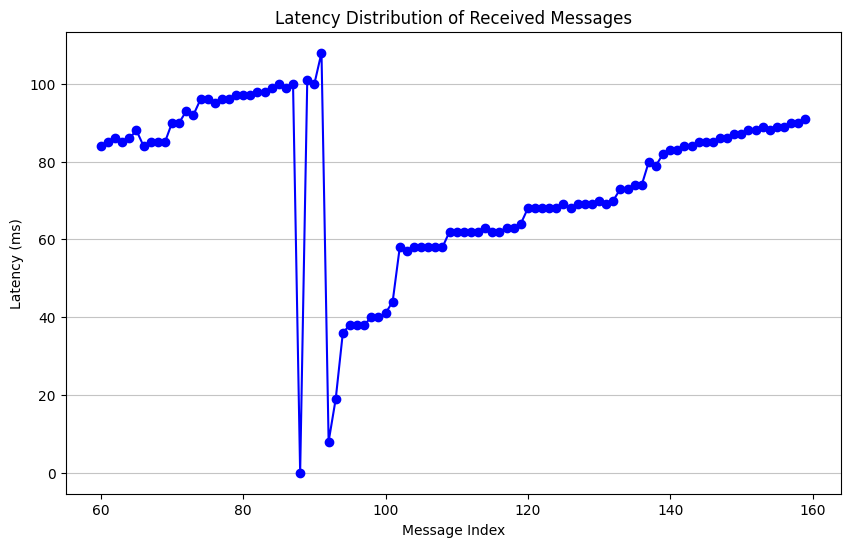

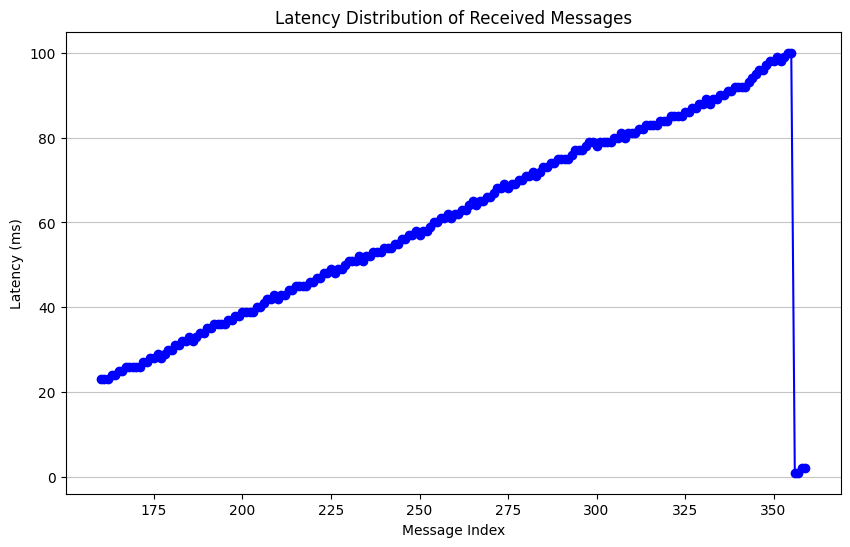

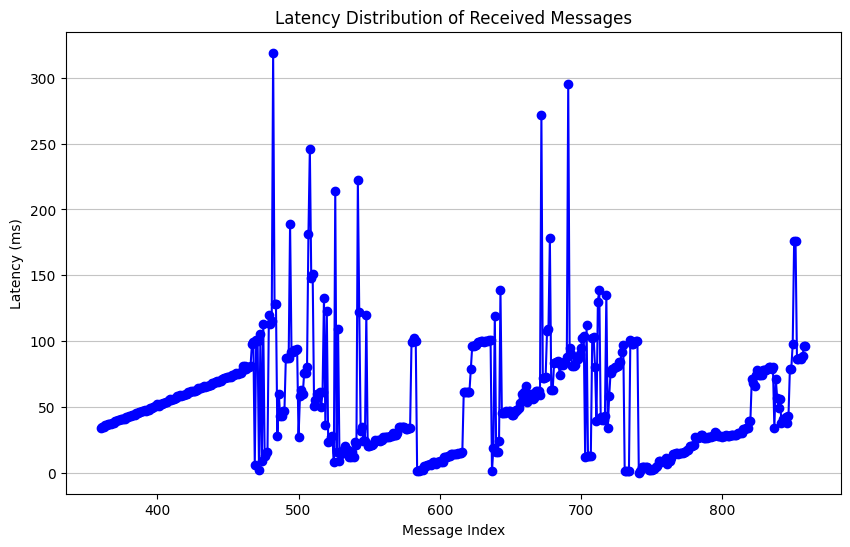

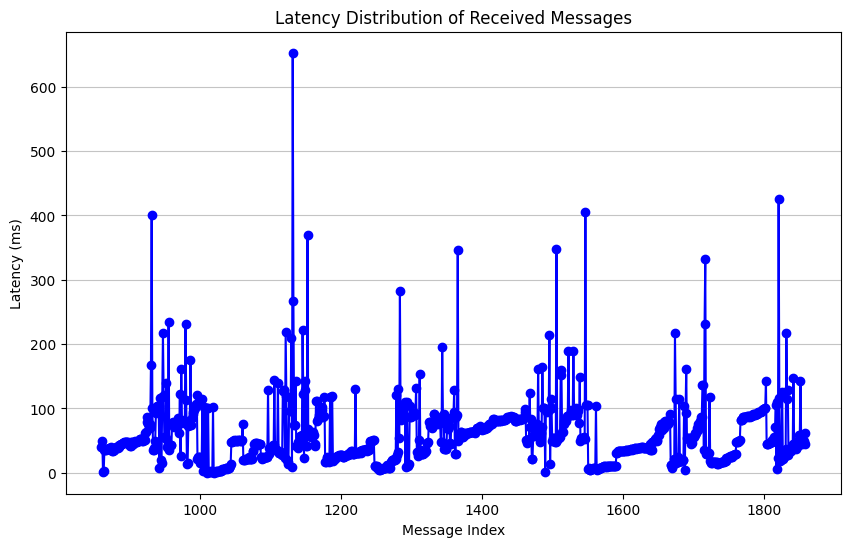

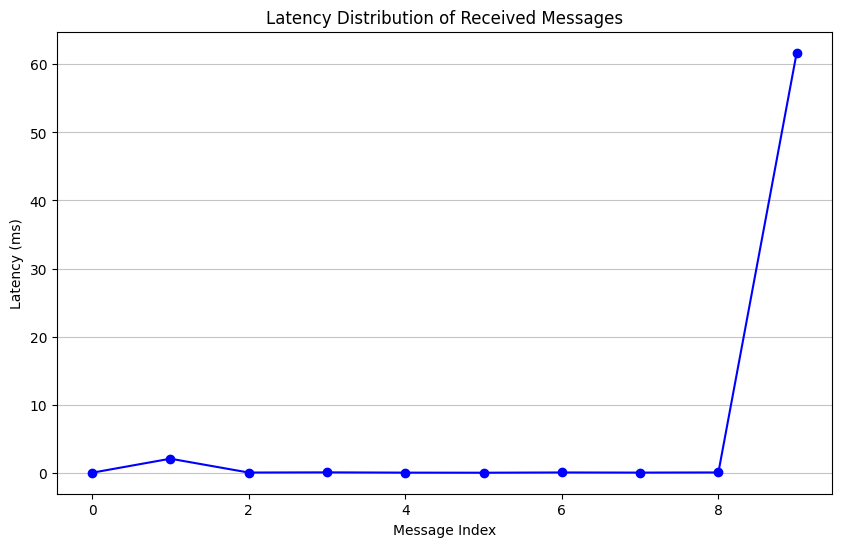

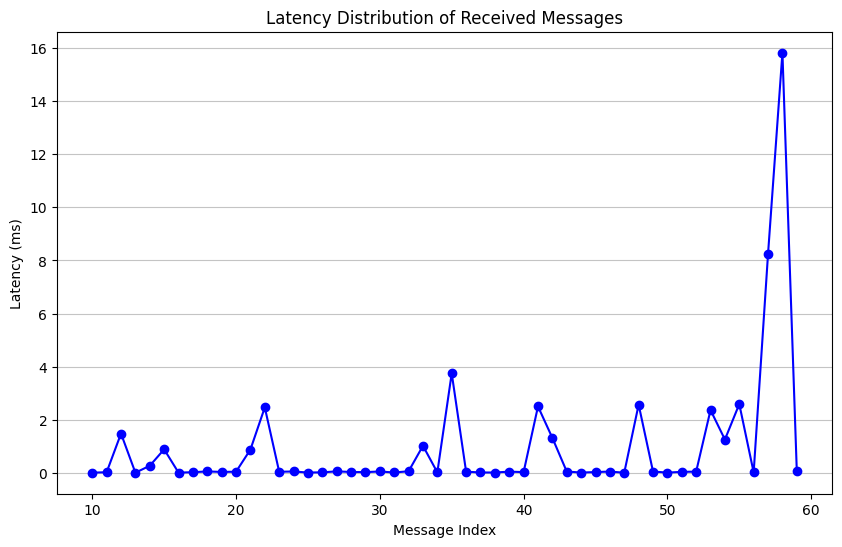

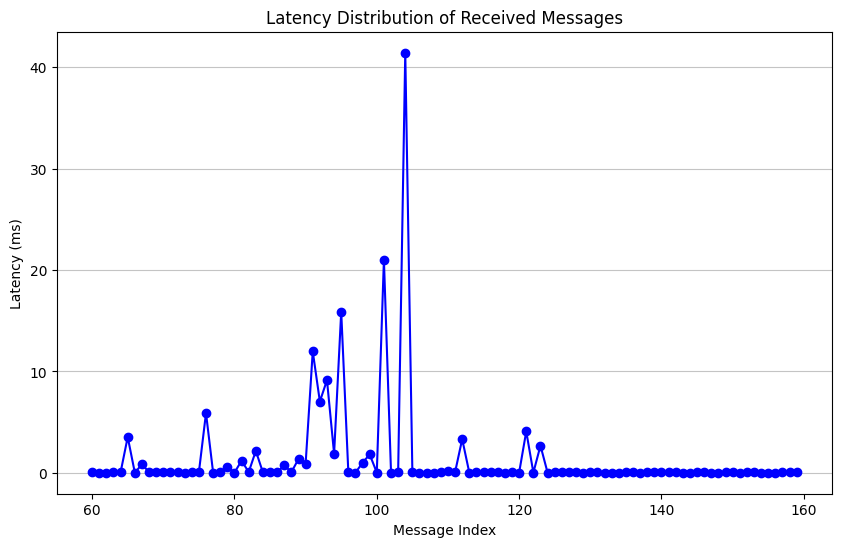

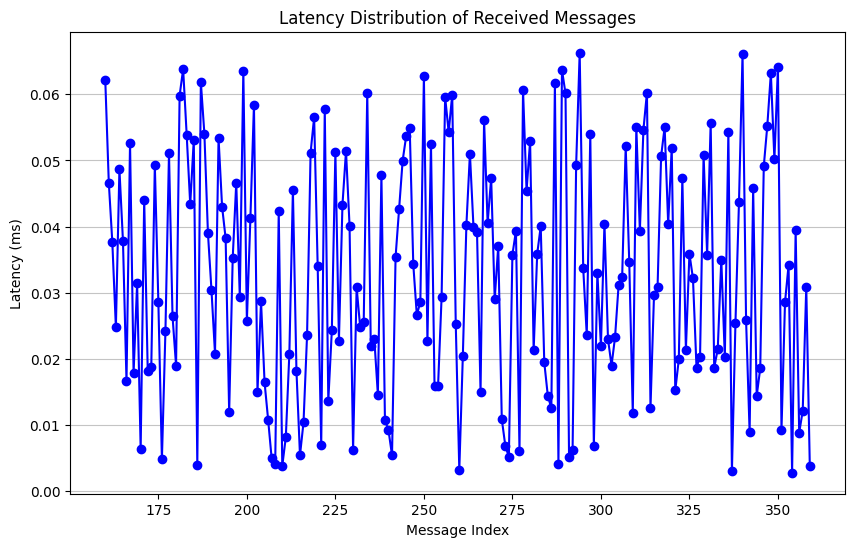

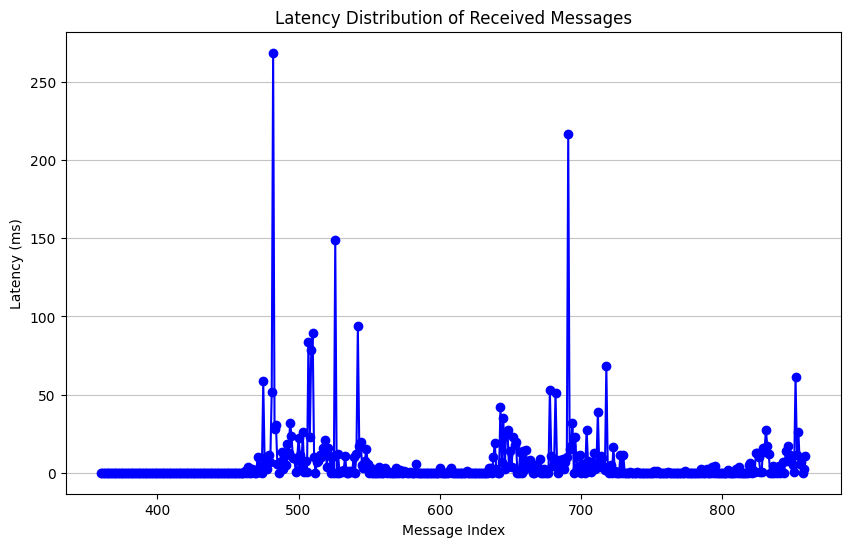

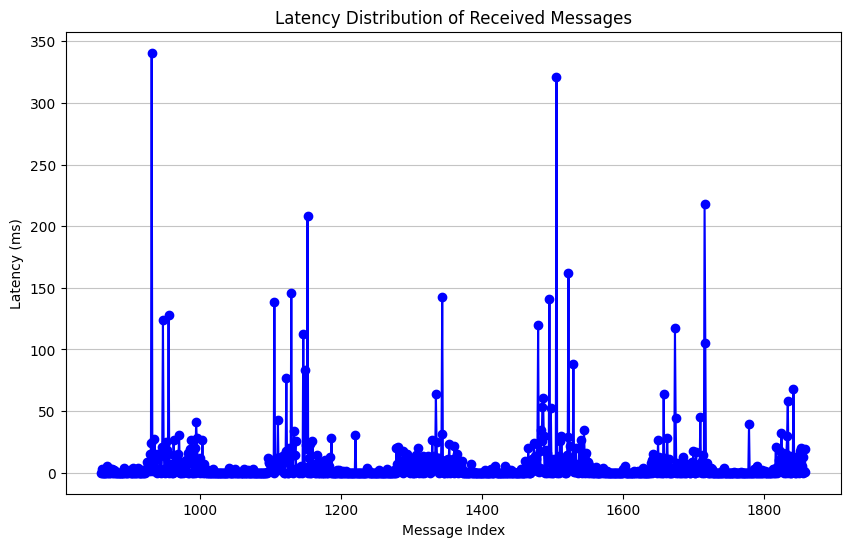

In [2]:
df = pd.read_csv('mensajes_recibidos2.csv')


df['latency'] = df['Receiving_Timestamp'] - df['Sending_Timestamp']

df.reset_index(inplace=True)



pruebas = [10, 50, 100, 200, 500, 1000]
lista = []
contador = 0
for prueba in pruebas:
    for i in range(0, prueba):
        lista.append(prueba)
        contador += 1



df['grupo'] = lista   

for prueba in pruebas:
    df2 = df[df['grupo'] == prueba]
    plt.figure(figsize=(10, 6))
    plt.plot(df2['index'], df2['latency'], marker='o', linestyle='-', color='blue')
    # plt.hist(df[df2]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_{prueba}.png')



print("Total messages processed:", contador)
print("Total messages dropped:", sum(pruebas) - contador)




fdf = pd.read_csv('resultados_experimento.csv')
ldf = pd.read_csv('resultados_experimento2.csv')


df['arrived_timestamp'] = fdf['timestamp_ns']
df['leaving_timestamp'] = ldf['timestamp_ns']

df['latency_s_s'] = (df['leaving_timestamp'] - df['arrived_timestamp'])/1000000



print(df)


for prueba in pruebas:
    df2 = df[df['grupo'] == prueba]
    plt.figure(figsize=(10, 6))
    plt.plot(df2['index'], df2['latency_s_s'], marker='o', linestyle='-', color='blue')
    # plt.hist(df[df2]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_s_s_{prueba}.png')
